### Quantum Computation — Assignment 2

**Albert Kabore**  
PhD student in Advanced and Equitable Computing

**Single-qubit states and the Pauli / Hadamard gates in Qiskit**

This notebook contains all the code for the assignment:

1. **Question 1** – numerically verify that
$|\psi\rangle = \frac{i}{2}|0\rangle + \frac{\sqrt{3}\,e^{i\pi/6}}{2}|1\rangle$ is normalised.
2. **Question 2** – build, draw, simulate and measure the circuits $H|0\rangle$, $Y|0\rangle$ and $Z|0\rangle$,
then compare the measured histograms with the mathematically predicted probabilities $P(|0\rangle)$ and $P(|1\rangle)$.

All figures are saved to the `figures/` folder so they can be inserted in the report.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

os.makedirs("figures", exist_ok=True)
SHOTS = 1024     # number of repetitions of each experiment
SEED = 42        # fixed seed so the results are reproducible

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
Python executable: C:\Users\alber\Quantum-Computation_Assignment_2\.venv311\Scripts\python.exe
Python version: 3.11.0


#### Question 1 - Normalisation

For $|\psi\rangle=\frac{i}{2}|0\rangle+\frac{\sqrt{3}e^{i\pi/6}}{2}|1\rangle$, the orthonormal basis gives

$$\langle\psi|\psi\rangle=|a_0|^2+|a_1|^2
=\frac{(-i)i}{4}+\frac{3e^{-i\pi/6}e^{i\pi/6}}{4}
=\frac14+\frac34=1.$$

Therefore $\|\psi\|=\sqrt{1}=1$, so the ket is a valid normalized state vector. The following cell checks the calculation numerically.


In [2]:
a0 = 1j / 2
a1 = np.sqrt(3) * np.exp(1j * np.pi / 6) / 2

print(f"a0 = {a0:.4f}")
print(f"a1 = {a1:.4f}   (= 3/4 + i*sqrt(3)/4 in Cartesian form)")
print(f"|a0|^2 = {abs(a0)**2:.4f}")
print(f"|a1|^2 = {abs(a1)**2:.4f}")
norm_sq = abs(a0)**2 + abs(a1)**2
print(f"|a0|^2 + |a1|^2 = {norm_sq:.4f}")

psi = Statevector([a0, a1])
print("Qiskit Statevector.is_valid():", psi.is_valid())
assert np.isclose(norm_sq, 1.0)

a0 = 0.0000+0.5000j
a1 = 0.7500+0.4330j   (= 3/4 + i*sqrt(3)/4 in Cartesian form)
|a0|^2 = 0.2500
|a1|^2 = 0.7500
|a0|^2 + |a1|^2 = 1.0000
Qiskit Statevector.is_valid(): True


#### Question 2 - Qiskit implementation

Each circuit starts in $|0\rangle$, applies H, Y, or Z, and measures qubit 0 into classical bit 0. The helper displays `qc.draw()` and `qc.draw("mpl")`, then plots the measurement histogram from 1024 ideal simulator shots (seed 42). The state vector before measurement provides a numerical check of the hand derivations below.


In [3]:
simulator = AerSimulator()

def run_single_qubit_circuit(gate_name):
    # 1) circuit with 1 qubit and 1 classical bit, qubit initialised to |0>
    qc = QuantumCircuit(1, 1)

    # 2) apply the requested gate using Qiskit's syntax
    getattr(qc, gate_name)(0)          # qc.h(0), qc.y(0) or qc.z(0)

    # 3) exact state vector before measurement (theory)
    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()

    # 4) measure qubit 0 into classical bit 0
    qc.measure(0, 0)

    # draw the circuit (text in the notebook + image for the report)
    print(qc.draw())
    fig_c = qc.draw("mpl", scale=0.6)
    fig_c.set_size_inches(fig_c.get_figwidth() * 2, fig_c.get_figheight())
    fig_c.savefig(f"figures/circuit_{gate_name}.png", dpi=200, bbox_inches="tight")
    display(fig_c)
    plt.close(fig_c)

    # simulate
    job = simulator.run(transpile(qc, simulator, seed_transpiler=SEED), shots=SHOTS, seed_simulator=SEED)
    counts = job.result().get_counts()
    counts = {k: counts.get(k, 0) for k in ("0", "1")}  # show both outcomes

    fig_h = plot_histogram(counts, title=f"{gate_name.upper()}|0>  ({SHOTS} shots)",
                           figsize=(6, 2.0))
    fig_h.savefig(f"figures/histogram_{gate_name}.png", dpi=200, bbox_inches="tight")
    display(fig_h)
    plt.close(fig_h)

    print("Statevector:", np.round(state.data, 4))
    print("Predicted  P(0) = %.4f   P(1) = %.4f" % (probs.get("0", 0), probs.get("1", 0)))
    print("Observed   f(0) = %.4f   f(1) = %.4f   counts = %s"
          % (counts["0"] / SHOTS, counts["1"] / SHOTS, counts))
    return qc, state, counts

#### (a) $H|0\rangle$

$$H = \frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix},\qquad
H|0\rangle = \frac{1}{\sqrt2}\begin{pmatrix}1\\1\end{pmatrix} = \frac{|0\rangle+|1\rangle}{\sqrt2} = |+\rangle$$

Prediction: $P(|0\rangle) = \left|\tfrac{1}{\sqrt2}\right|^2 = 0.5$, $P(|1\rangle) = 0.5$ → roughly 512 counts each.

To see the matrix multiplication explicitly (each row times the input column):

$$H|0\rangle=\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\frac{1}{\sqrt2}\begin{pmatrix}1\cdot1+1\cdot0\\1\cdot1+(-1)\cdot0\end{pmatrix}$$

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


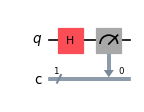

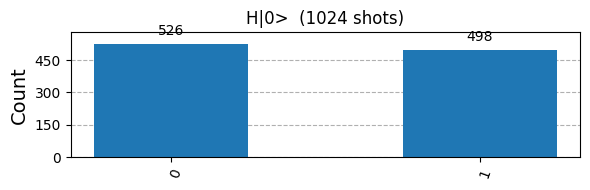

Statevector: [0.7071+0.j 0.7071+0.j]
Predicted  P(0) = 0.5000   P(1) = 0.5000
Observed   f(0) = 0.5137   f(1) = 0.4863   counts = {'0': 526, '1': 498}


In [4]:
qc_h, state_h, counts_h = run_single_qubit_circuit("h")

#### (b) $Y|0\rangle$

$$Y = \begin{pmatrix}0&-i\\ i&0\end{pmatrix},\qquad
Y|0\rangle = \begin{pmatrix}0\\ i\end{pmatrix} = i|1\rangle$$

Prediction: $P(|0\rangle) = 0$, $P(|1\rangle) = |i|^2 = 1$ → all 1024 counts in `1`.
(The factor $i$ is a *global phase* and cannot be seen by a measurement.)

To see the matrix multiplication explicitly (each row times the input column):

$$Y|0\rangle=\begin{pmatrix}0&-i\\i&0\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\begin{pmatrix}0\cdot1+(-i)\cdot0\\i\cdot1+0\cdot0\end{pmatrix}$$

     ┌───┐┌─┐
  q: ┤ Y ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


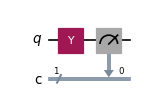

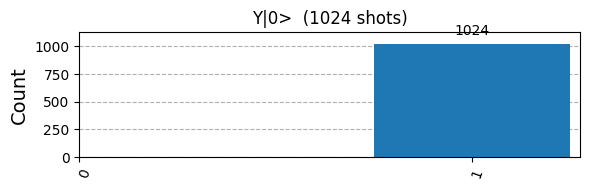

Statevector: [0.+0.j 0.+1.j]
Predicted  P(0) = 0.0000   P(1) = 1.0000
Observed   f(0) = 0.0000   f(1) = 1.0000   counts = {'0': 0, '1': 1024}


In [5]:
qc_y, state_y, counts_y = run_single_qubit_circuit("y")

#### (c) $Z|0\rangle$

$$Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix},\qquad
Z|0\rangle = \begin{pmatrix}1\\0\end{pmatrix} = |0\rangle$$

Prediction: $P(|0\rangle) = 1$, $P(|1\rangle) = 0$ → all 1024 counts in `0`.

To see the matrix multiplication explicitly (each row times the input column):

$$Z|0\rangle=\begin{pmatrix}1&0\\0&-1\end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix}=\begin{pmatrix}1\cdot1+0\cdot0\\0\cdot1+(-1)\cdot0\end{pmatrix}$$

Z leaves the input $|0\rangle$ unchanged.


     ┌───┐┌─┐
  q: ┤ Z ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


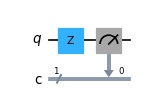

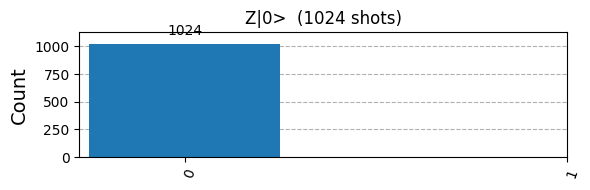

Statevector: [1.+0.j 0.+0.j]
Predicted  P(0) = 1.0000   P(1) = 0.0000
Observed   f(0) = 1.0000   f(1) = 0.0000   counts = {'0': 1024, '1': 0}


In [6]:
qc_z, state_z, counts_z = run_single_qubit_circuit("z")

#### Verification - predictions and measurements

Compare the predicted probabilities with the observed frequencies (counts divided by 1024). H gives approximately equal frequencies, with finite sampling fluctuations. Y always gives 1 and Z always gives 0 in this ideal simulation. The checks below also compare the computed state vectors with the hand-derived amplitudes.


In [7]:
rows = [("H|0>", state_h, counts_h), ("Y|0>", state_y, counts_y), ("Z|0>", state_z, counts_z)]

print(f"{'Circuit':<8}{'Pred P(0)':>11}{'Pred P(1)':>11}{'Obs f(0)':>11}{'Obs f(1)':>11}{'Counts':>22}")
for name, st, cnt in rows:
    p = st.probabilities_dict()
    print(f"{name:<8}{p.get('0',0):>11.3f}{p.get('1',0):>11.3f}"
          f"{cnt['0']/SHOTS:>11.3f}{cnt['1']/SHOTS:>11.3f}{str(cnt):>22}")

# Compare against the independently hand-derived amplitudes and probabilities.
expected = [(state_h, [1 / np.sqrt(2), 1 / np.sqrt(2)], [0.5, 0.5]),
            (state_y, [0, 1j], [0, 1]),
            (state_z, [1, 0], [1, 0])]
for state, amplitudes, probabilities in expected:
    assert np.allclose(state.data, amplitudes)
    assert np.allclose(state.probabilities(), probabilities)
    assert state.is_valid()
for _, _, counts in rows:
    assert sum(counts.values()) == SHOTS

# Deterministic outcomes must match exactly.
assert counts_y == {"0": 0, "1": SHOTS}
assert counts_z == {"0": SHOTS, "1": 0}
print("\nExact states match the hand derivations; sampled histograms are consistent with the predictions.")

Circuit   Pred P(0)  Pred P(1)   Obs f(0)   Obs f(1)                Counts
H|0>          0.500      0.500      0.514      0.486  {'0': 526, '1': 498}
Y|0>          0.000      1.000      0.000      1.000   {'0': 0, '1': 1024}
Z|0>          1.000      0.000      1.000      0.000   {'0': 1024, '1': 0}

Exact states match the hand derivations; sampled histograms are consistent with the predictions.


#### Report

`Assignment2_Report_Revised.docx` contains the normalization proof, the H/Y/Z state-vector derivations and predicted probabilities, circuit images, measurement histograms, and comparisons with the Qiskit results.
